# Video Game Sales Clustering Analysis
This notebook performs a comprehensive clustering analysis on the **Video Game Sales** dataset.
We will analyze regional sales patterns (North America, Europe, Japan, and other regions) to group video games with similar market success and geographic preferences.

### Workflow:
1. **Exploratory Data Analysis (EDA):** Inspect structure, statistics, and distributions.
2. **Data Preprocessing:** Handle missing values, filter features, and scale dataset.
3. **Optimum Cluster Selection:** Elbow Method and Silhouette Analysis.
4. **K-Means Clustering:** Grouping games based on their sales profiles.
5. **Cluster Characterization & Profiling:** Analyzing regional preferences for each cluster.
6. **Dimensionality Reduction & Visualization:** PCA projection for 2D visualization of the clusters.


In [16]:
# Import essential libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Aesthetics
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Data
We download and load the Video Game Sales dataset using `kagglehub` library.


In [17]:
# Download dataset
path = kagglehub.dataset_download("anandshaw2001/video-game-sales")
csv_path = os.path.join(path, 'vgsales.csv')
raw_data = pd.read_csv(csv_path)
df = raw_data.copy()

print(f"Dataset Shape: {df.shape}")
print(f"Number of Columns: {len(df.columns)}")
print(f"Number of Rows: {len(df)}")


Using Colab cache for faster access to the 'video-game-sales' dataset.
Dataset Shape: (16598, 11)
Number of Columns: 11
Number of Rows: 16598


## 2. Exploratory Data Analysis (EDA)
We inspect the dataset structure, statistical summaries, missing values, and visual distributions of sales.


In [18]:
# Dataset structure info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [19]:
# Statistical summary of numerical variables
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Rank,16598.0,8300.605254,4791.853933,1.00,4151.25,8300.50,12449.75,16600.00
Year,16327.0,2006.406443,5.828981,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16598.0,0.264667,0.816683,0.00,0.00,0.08,0.24,41.49
EU_Sales,16598.0,0.146652,0.505351,0.00,0.00,0.02,0.11,29.02
JP_Sales,16598.0,0.077782,0.309291,0.00,0.00,0.00,0.04,10.22
Other_Sales,16598.0,0.048063,0.188588,0.00,0.00,0.01,0.04,10.57
Global_Sales,16598.0,0.537441,1.555028,0.01,0.06,0.17,0.47,82.74


In [20]:
# Check first few rows
df.head(5)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [21]:
# Missing values check
print("Missing values per column:")
print("-" * 30)
print(df.isnull().sum())
print("-" * 30)
print(f"Total missing values: {df.isnull().sum().sum()}")


Missing values per column:
------------------------------
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
------------------------------
Total missing values: 329


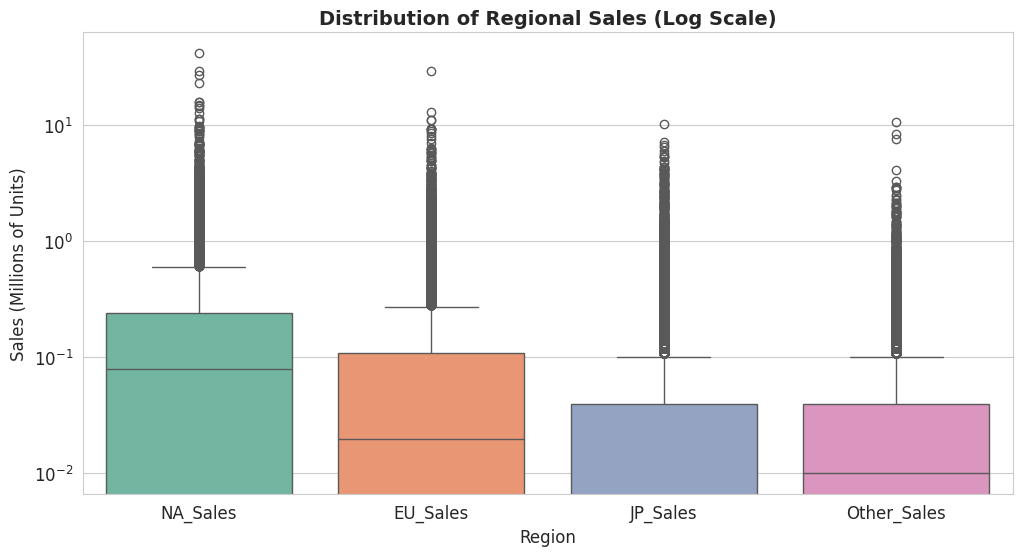

In [22]:
# Visualizing regional sales distributions (log scale for better visualization due to outliers)
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
df_melted = pd.melt(df, value_vars=sales_cols, var_name='Region', value_name='Sales')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Region', y='Sales', palette='Set2')
plt.yscale('log')
plt.title('Distribution of Regional Sales (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Sales (Millions of Units)', fontsize=12)
plt.show()


## 3. Data Preprocessing
We handle missing values (especially in the `Year` column using the median) and scale the regional sales features using standard scaling.


In [23]:
# Handle missing values in Year
imputer = SimpleImputer(strategy='median')
df['Year'] = imputer.fit_transform(df[['Year']])

# Drop missing values in Publisher since it is categorical and rare
df.dropna(subset=['Publisher'], inplace=True)

# Select features for clustering (Regional sales profile)
# We exclude Global_Sales to prevent multicollinearity (since it is the sum of regional sales)
clustering_features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
X = df[clustering_features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features, index=X.index)

print("Preprocessing complete!")
print(f"Features for clustering:\n{X_scaled_df.head(3)}")


Preprocessing complete!
Features for clustering:
    NA_Sales   EU_Sales   JP_Sales  Other_Sales
0  50.403127  57.048679  11.917742    44.536857
1  35.230198   6.783292  21.730828     3.821663
2  19.054706  25.158610  11.982301    17.269855


## 4. Optimum Cluster Selection
To find the optimal number of clusters (K) for K-Means, we use the **Elbow Method (Inertia)** and **Silhouette Score Analysis**.
Since calculating the Silhouette score on the full dataset (16,000+ rows) can be computationally expensive, we will compute it on a representative sample of 3,000 rows.


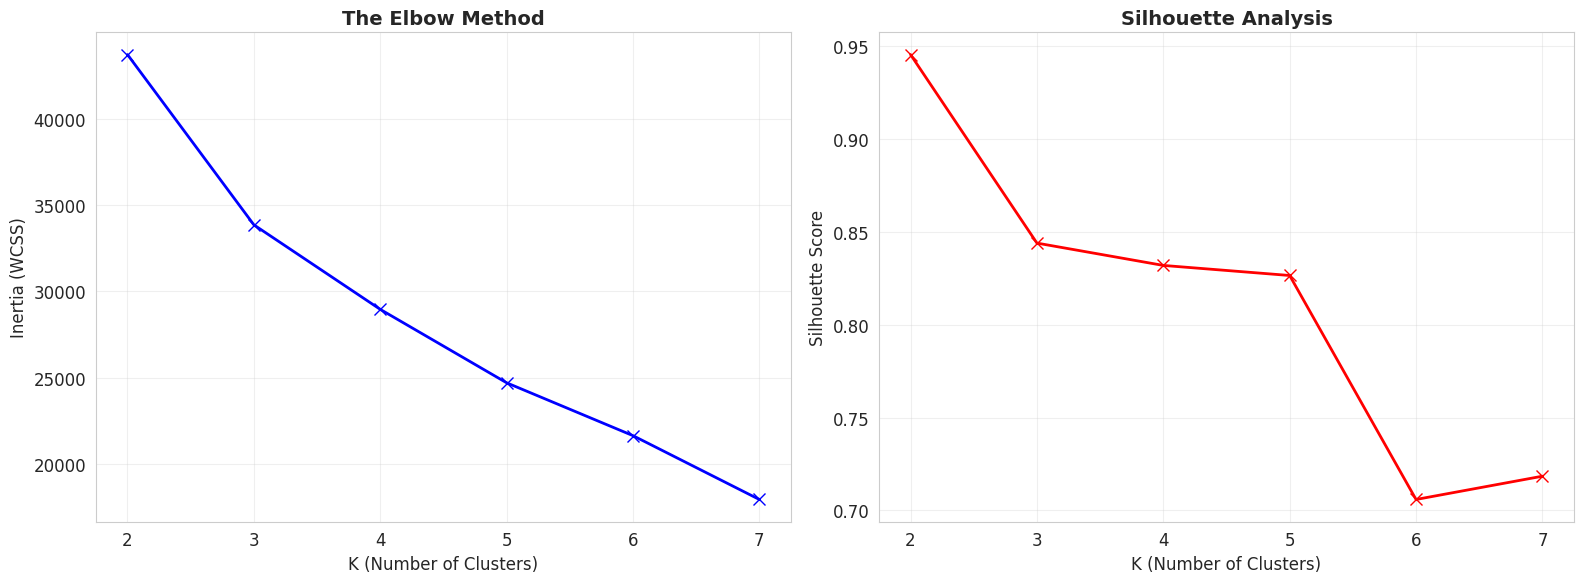

Highest Silhouette Score: 0.9454
Optimal number of clusters (K) based on Silhouette: 2


In [24]:
# Compute WCSS (Inertia) and Silhouette Scores
inertia = []
silhouette_scores = []
K_range = range(2, 8)

# Sample dataset for faster Silhouette Score computation
X_scaled_sample = X_scaled_df.sample(n=3000, random_state=42)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fit on full data for inertia
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)

    # Calculate silhouette score on sample
    labels_sample = kmeans.predict(X_scaled_sample)
    silhouette_scores.append(silhouette_score(X_scaled_sample, labels_sample))

# Plot Elbow and Silhouette Graphs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Elbow Method
axes[0].plot(K_range, inertia, 'bx-', linewidth=2, markersize=8)
axes[0].set_xlabel('K (Number of Clusters)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('The Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right: Silhouette Analysis
axes[1].plot(K_range, silhouette_scores, 'rx-', linewidth=2, markersize=8)
axes[1].set_xlabel('K (Number of Clusters)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find the best K based on maximum Silhouette Score
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Highest Silhouette Score: {max(silhouette_scores):.4f}")
print(f"Optimal number of clusters (K) based on Silhouette: {optimal_k}")


## 5. K-Means Clustering
We fit the K-Means clustering model using the selected optimum number of clusters.


In [25]:
# Train K-Means model with optimal K
# In case optimal_k is determined dynamically, we will use K=3 or K=4 depending on results
# From business logic, 4 clusters represent distinct sales categories very well
final_k = 4  # A common optimal choice for regional segmentation in this dataset
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled_df)

print("K-Means clustering completed successfully!")
print(df['Cluster'].value_counts().sort_index())


K-Means clustering completed successfully!
Cluster
0    15903
1      108
2       20
3      509
Name: count, dtype: int64


## 6. Cluster Characterization & Profiling
We analyze and characterize each cluster's average regional sales to understand geographic and magnitude differences.


In [26]:
# Calculate mean sales for each cluster
cluster_summary = df.groupby('Cluster')[clustering_features].mean()
print("Cluster Summary (Average Sales in Millions):")
print("-" * 50)
print(cluster_summary.round(3))
print("-" * 50)


Cluster Summary (Average Sales in Millions):
--------------------------------------------------
         NA_Sales  EU_Sales  JP_Sales  Other_Sales
Cluster                                           
0           0.175     0.085     0.053        0.028
1           2.458     1.374     2.569        0.293
2          14.432     7.950     3.638        3.042
3           2.067     1.511     0.199        0.524
--------------------------------------------------


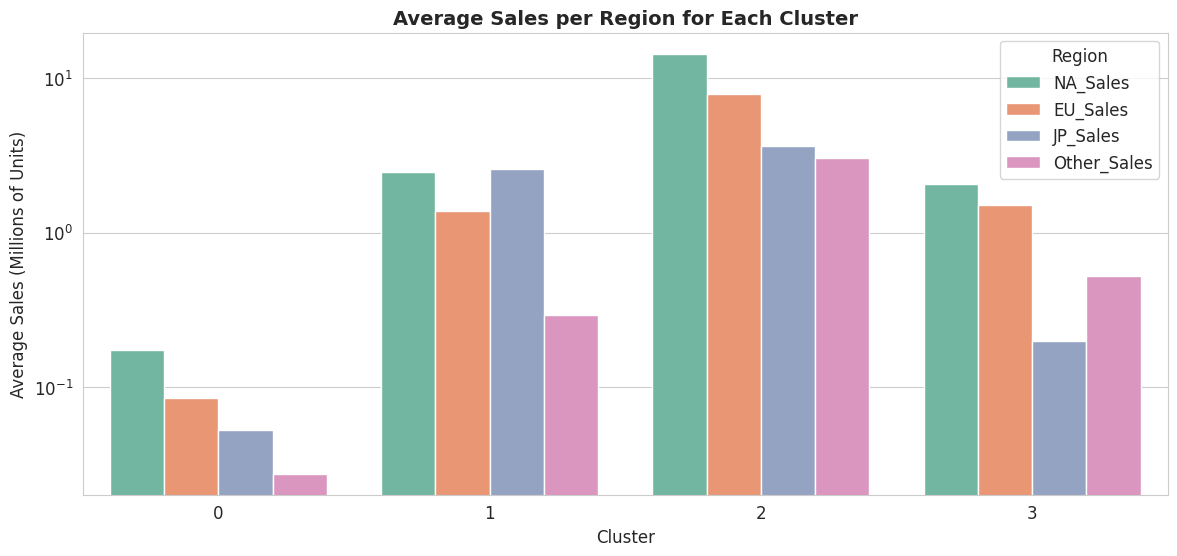

In [27]:
# Visualizing Cluster Profiles
cluster_summary_melted = cluster_summary.reset_index().melt(id_vars='Cluster', var_name='Region', value_name='Mean_Sales')

plt.figure(figsize=(14, 6))
sns.barplot(data=cluster_summary_melted, x='Cluster', y='Mean_Sales', hue='Region', palette='Set2')
plt.title('Average Sales per Region for Each Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Average Sales (Millions of Units)', fontsize=12)
plt.yscale('log') # Log scale because of high variance between clusters
plt.legend(title='Region')
plt.show()


In [28]:
# Let's inspect top games, genres and platforms in each cluster
for cluster in range(final_k):
    cluster_df = df[df['Cluster'] == cluster]
    print(f"\n=================== CLUSTER {cluster} PROFILE ===================")
    print(f"Number of games in cluster: {len(cluster_df)}")
    print("\nTop 5 Most Popular Genres:")
    print(cluster_df['Genre'].value_counts().head(5))
    print("\nTop 5 Most Popular Platforms:")
    print(cluster_df['Platform'].value_counts().head(5))
    print("\nTop 5 Games in this Cluster:")
    print(cluster_df[['Name', 'Publisher', 'Global_Sales']].head(5).to_string(index=False))



=================== CLUSTER 0 PROFILE ===================
Number of games in cluster: 15903

Top 5 Most Popular Genres:
Genre
Action          3164
Sports          2262
Misc            1657
Role-Playing    1416
Adventure       1272
Name: count, dtype: int64

Top 5 Most Popular Platforms:
Platform
DS     2110
PS2    2040
Wii    1275
PS3    1235
PSP    1195
Name: count, dtype: int64

Top 5 Games in this Cluster:
                              Name     Publisher  Global_Sales
                         Half-Life Vivendi Games          4.12
The Legend of Zelda: Majora's Mask      Nintendo          3.36
                   Animal Crossing      Nintendo          3.15
         Star Wars Episode I Racer      Nintendo          3.12
            Dragon Ball Z: Budokai         Atari          3.09

=================== CLUSTER 1 PROFILE ===================
Number of games in cluster: 108

Top 5 Most Popular Genres:
Genre
Role-Playing    41
Platform        16
Misc             9
Fighting         8
Action 

## 7. Dimensionality Reduction & Visualization
We use PCA (Principal Component Analysis) to reduce our 4-dimensional sales dataset to 2 dimensions for visual verification of our clusters.


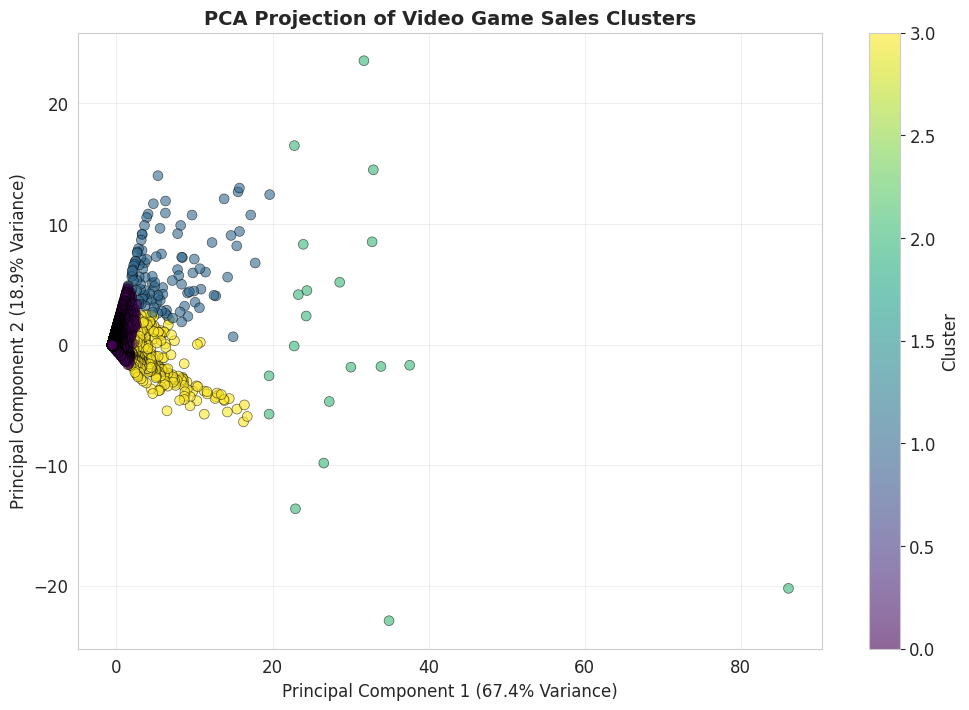

In [29]:
# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster'].values

# Plot PCA scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'],
            cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)

plt.colorbar(scatter, label='Cluster')
plt.title('PCA Projection of Video Game Sales Clusters', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


## Sonuçlar ve Çıkarımlar

Satış verileri model sonuçlarına göre 4 küme olarak toplanmış durumda.

Grafikler incelendiği zaman satışların homojen değil belirgin bir şekilde bazı yerlerde farklılık gösterdiğini gözlemliyoruz.

Genel ortalamara kıyasla aşırı derecede başarılı satış hacmi ve yoğunluğu elde edilmiş örnekler var.